# Лабораторная работа №3
## Fine-tuning Stable Diffusion: LoRA и DreamBooth

**Курс:** Генеративные и мультимодальные сети
**Максимальный балл:** 25  

---

### Цель работы
Освоить методы эффективной адаптации предобученной text-to-image модели под кастомный домен.  
Сравнить подходы LoRA (Low-Rank Adaptation) и DreamBooth.

### Система оценки
| Задание | Баллы |
|---------|-------|
| Подготовка датасета и описание выбора объекта | 3 |
| Успешный fine-tuning с LoRA | 8 |
| Успешный fine-tuning с DreamBooth | 7 |
| Сравнительный анализ (таблица + выводы) | 5 |
| Анализ проблем (overfitting, language drift) | 2 |

### Что сдавать
- Заполненный ноутбук

### ⚠️ Требования к GPU
- LoRA: GPU ≥ 8 GB VRAM (Google Colab T4 подойдёт)
- DreamBooth: GPU ≥ 16 GB VRAM рекомендуется (Colab Pro / A100)
- Альтернатива: использовать `--gradient_checkpointing` и `--mixed_precision=fp16`


## 0. Установка зависимостей


In [ ]:
!pip install diffusers transformers accelerate peft torch torchvision \
             bitsandbytes xformers wandb Pillow --quiet
# Проверка версий
import diffusers, transformers, peft
print(f'diffusers: {diffusers.__version__}')
print(f'transformers: {transformers.__version__}')
print(f'peft: {peft.__version__}')


## 1. Импорты


In [1]:
import torch
import os
import math
import itertools
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np

from diffusers import StableDiffusionPipeline, DDPMScheduler, AutoencoderKL, UNet2DConditionModel
from diffusers.optimization import get_scheduler
from transformers import CLIPTextModel, CLIPTokenizer
from peft import LoraConfig, get_peft_model
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from accelerate import Accelerator

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')


Устройство: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 2. Подготовка датасета

> **Задание:** Соберите 15–25 изображений одного объекта, персонажа или стиля.
> 
> **Идеи для датасета:**
> - Конкретная порода собаки/кошки (из открытых датасетов)
> - Художественный стиль (импрессионизм, пиксель-арт)
> - Конкретный объект (ваша кружка, игрушка, ...)
> - Персонаж из аниме/мультфильма
> 
> **Требования к изображениям:**
> - Разрешение ≥ 512×512 (будут масштабированы до 512×512)
> - Разнообразные позы/ракурсы/освещение
> - Минимум артефактов, размытости


DataLoader готов (batch_size=2, num_workers=4)
Mixed Precision (FP16) активирован через GradScaler
Найдено изображений: 18


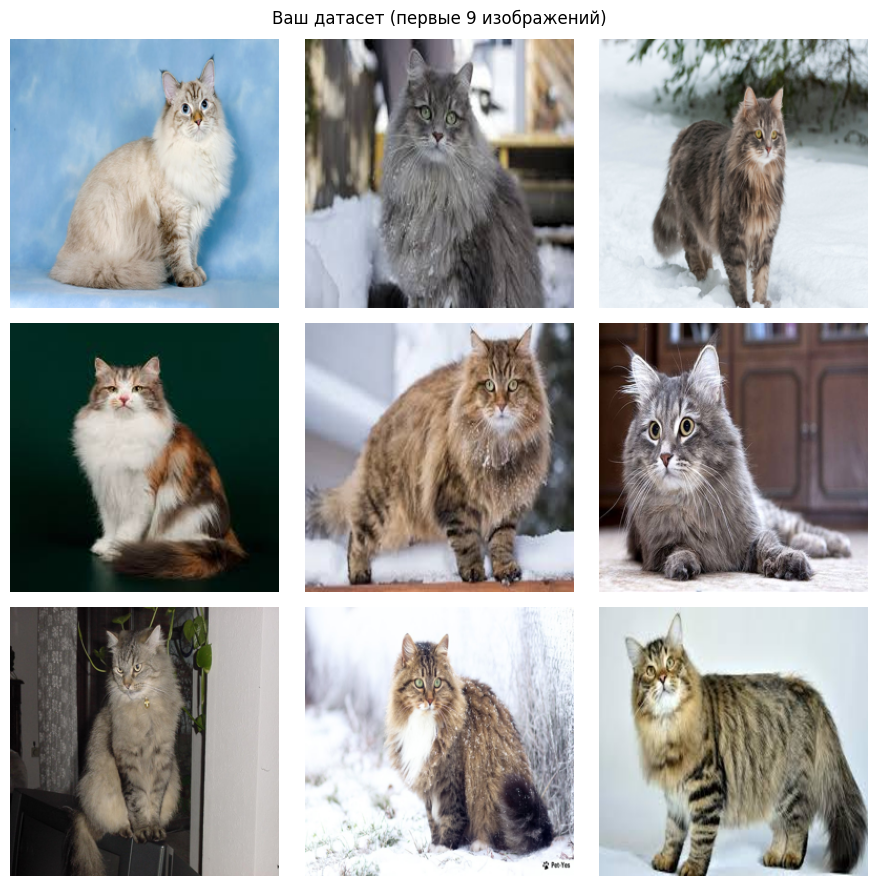

In [8]:
NUM_WORKERS = 4
PIN_MEMORY = True
BATCH_SIZE = 2
IMAGE_SIZE = 512

# Путь к датасету
DATASET_DIR = '/kaggle/input/datasets/makhamuddrame/my-style-data/Сиб_кошка'
os.makedirs(DATASET_DIR, exist_ok=True)

# TODO: Опишите ваш датасет
DATASET_DESCRIPTION = """
# Объект: [Например: Корги]
# Источник изображений: [Например: Pinterest / Kaggle Datasets]
# Количество изображений: [Например: 20]
# Разнообразие: [Например: Разные ракурсы, освещение, в помещении и на улице]
"""

# Класс датасета для Stable Diffusion (базовый вариант)
class DreamBoothDataset(Dataset):
    def __init__(self, folder, size=512):
        self.folder = Path(folder)
        self.images = list(self.folder.glob('*.jpg')) + list(self.folder.glob('*.png'))
        self.transform = transforms.Compose([
            transforms.Resize(size, interpolation=transforms.InterpolationMode.BILINEAR),
            transforms.CenterCrop(size),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.images)

    def __getitem__(self, i):
        img = Image.open(self.images[i]).convert("RGB")
        return self.transform(img)

# Проверка и визуализация датасета
def show_dataset(folder, n=9):
    images = list(Path(folder).glob('*.jpg')) + list(Path(folder).glob('*.png'))
    if not images:
        print(f"В папке {folder} пока нет изображений. Загрузи их!")
        return
    
    print(f'Найдено изображений: {len(images)}')
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))
    for ax, img_path in zip(axes.flat, images[:n]):
        img = Image.open(img_path).convert("RGB").resize((256, 256))
        ax.imshow(img)
        ax.axis('off')
    plt.suptitle('Ваш датасет (первые 9 изображений)')
    plt.tight_layout()
    plt.show()



dataset = DreamBoothDataset(DATASET_DIR, size=IMAGE_SIZE)
train_dataloader = DataLoader(
    dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY
)

# Инициализация Mixed Precision (FP16)
# Используем torch.amp 
scaler = torch.amp.GradScaler('cuda')

print(f"DataLoader готов (batch_size={BATCH_SIZE}, num_workers={NUM_WORKERS})")
print(f"Mixed Precision (FP16) активирован через GradScaler")


show_dataset(DATASET_DIR)

In [9]:
class DreamBoothDataset(Dataset):
    """Датасет для DreamBooth и LoRA обучения."""

    def __init__(self, image_dir, instance_prompt, tokenizer, size=512):
        self.image_dir = Path(image_dir)
        self.instance_prompt = instance_prompt
        self.tokenizer = tokenizer
        self.size = size

        self.image_paths = list(self.image_dir.glob('*.jpg')) + \
                           list(self.image_dir.glob('*.png'))
        print(f'Загружено {len(self.image_paths)} изображений')

        self.transform = transforms.Compose([
            transforms.Resize((size, size)),
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5]),
        ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert('RGB')
        pixel_values = self.transform(img)

        # Токенизация промпта
        input_ids = self.tokenizer(
            self.instance_prompt,
            truncation=True,
            padding='max_length',
            max_length=self.tokenizer.model_max_length,
            return_tensors='pt',
        ).input_ids[0]

        return {'pixel_values': pixel_values, 'input_ids': input_ids}


## 3. Загрузка предобученной модели

> Используем `runwayml/stable-diffusion-v1-5` или `stabilityai/stable-diffusion-2-1-base`.
> Для экономии памяти загружаем в `fp16`.


In [5]:
MODEL_ID = 'runwayml/stable-diffusion-v1-5'  # или 'stabilityai/stable-diffusion-2-1-base'

print(f'Загружаем компоненты из {MODEL_ID}...')

tokenizer  = CLIPTokenizer.from_pretrained(MODEL_ID, subfolder='tokenizer')
text_encoder = CLIPTextModel.from_pretrained(MODEL_ID, subfolder='text_encoder', torch_dtype=torch.float16)
vae        = AutoencoderKL.from_pretrained(MODEL_ID, subfolder='vae', torch_dtype=torch.float16)
unet       = UNet2DConditionModel.from_pretrained(MODEL_ID, subfolder='unet', torch_dtype=torch.float16)
noise_scheduler = DDPMScheduler.from_pretrained(MODEL_ID, subfolder='scheduler')



# Замораживаем VAE и text_encoder (обучаем только UNet через LoRA)
vae.requires_grad_(False)
text_encoder.requires_grad_(False)

vae.to(device)
text_encoder.to(device)
unet.to(device)

print('Модель загружена!')
print(f'Параметры UNet: {sum(p.numel() for p in unet.parameters()) / 1e6:.1f}M')


Загружаем компоненты из runwayml/stable-diffusion-v1-5...


tokenizer_config.json:   0%|          | 0.00/806 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/472 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

scheduler_config.json:   0%|          | 0.00/308 [00:00<?, ?B/s]

Модель загружена!
Параметры UNet: 859.5M


## 4. LoRA Fine-tuning

> **Задание:** Добавьте LoRA-адаптеры к attention-слоям UNet и обучите только их.
> 
> **Что такое LoRA:**  
> Вместо обновления матрицы весов W (m×n), обучаем две малые матрицы A (m×r) и B (r×n),  
> где r << min(m,n) — это и есть **rank**. Обновление: ΔW = B·A.
> 
> **Параметры для экспериментов:**
> - `r` (rank): 4, 8, 16 — попробуйте разные
> - `lora_alpha`: обычно равен rank или rank*2
> - `target_modules`: слои для адаптации


In [10]:
# TODO: Настройте LoRA конфигурацию
lora_config = LoraConfig(
    r=16,                   # Выбрали 16 для более детального захвата черт сибирской кошки
    lora_alpha=16,          # Scaling factor 
    target_modules=[
        'to_q', 'to_k', 'to_v', 'to_out.0',  # cross-attention (основные слои)
        'proj_in', 'proj_out',               # добавили для лучшей адаптации стиля
    ],
    lora_dropout=0.1,
    bias='none',
)

# Применяем LoRA к UNet
unet_lora = get_peft_model(unet, lora_config)

# должно быть << 1% от полных параметров
unet_lora.print_trainable_parameters()  

# Обучаем в fp32 для стабильности
unet_lora = unet_lora.to(torch.float32) 

# Переносим на GPU 
unet_lora.to(device)

print("\n LoRA адаптеры успешно добавлены.")
print(f"Используемый ранг (r): {lora_config.r}")

trainable params: 3,987,456 || all params: 863,508,420 || trainable%: 0.4618

 LoRA адаптеры успешно добавлены.
Используемый ранг (r): 16


In [11]:
# Конфигурация обучения LoRA
INSTANCE_PROMPT = 'a photo of sks sibcat'  # TODO: замените 'object' на описание вашего объекта
LORA_OUTPUT_DIR = './lora_weights'
LORA_EPOCHS = 100
LORA_LR = 1e-4

os.makedirs(LORA_OUTPUT_DIR, exist_ok=True)

# Датасет и загрузчик 
train_dataset = DreamBoothDataset(
    image_dir=DATASET_DIR,
    instance_prompt=INSTANCE_PROMPT,
    tokenizer=tokenizer,
    size=IMAGE_SIZE
)

# Используем num_workers=4 и pin_memory=True для быстрой загрузки
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

optimizer_lora = torch.optim.AdamW(unet_lora.parameters(), lr=LORA_LR, weight_decay=1e-2)
lr_scheduler = get_scheduler(
    'cosine', 
    optimizer=optimizer_lora,
    num_warmup_steps=50,
    num_training_steps=LORA_EPOCHS * len(train_loader)
)

# Инициализация GradScaler для Mixed Precision (float16)
scaler = torch.amp.GradScaler('cuda')

lora_losses = []

print(f"Начинаем обучение: {LORA_EPOCHS} эпох, батч {len(train_dataset)} (из-за малого кол-ва фото)")

for epoch in range(LORA_EPOCHS):
    unet_lora.train()
    epoch_loss = 0

    for batch in train_loader:
        # Переносим данные на GPU
        pixel_values = batch['pixel_values'].to(device, non_blocking=True)
        input_ids    = batch['input_ids'].to(device, non_blocking=True)

        # Используем autocast для Mixed Precision (ускорение в 16-бит)
        with torch.amp.autocast('cuda'):
            # TODO: Кодируем изображение в латентное пространство через VAE
            with torch.no_grad():
                latents = vae.encode(pixel_values.to(torch.float16)).latent_dist.sample()
                latents = latents * vae.config.scaling_factor

            # TODO: Добавляем шум к латентам (случайный timestep)
            noise = torch.randn_like(latents)
            bsz = latents.shape[0]
            timesteps = torch.randint(0, noise_scheduler.config.num_train_timesteps,
                                      (bsz,), device=device).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)

            # TODO: Получаем text embeddings
            with torch.no_grad():
                encoder_hidden_states = text_encoder(input_ids)[0]

            # TODO: Предсказание шума через UNet
            noise_pred = unet_lora(
                noisy_latents,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
            ).sample

            # TODO: MSE loss
            loss = torch.nn.functional.mse_loss(noise_pred.float(), noise.float())

        # Обратное распространение с использованием Scaler (защита от потери точности в fp16)
        optimizer_lora.zero_grad()
        scaler.scale(loss).backward()
        
        # Градиентный клиппинг (нужен нескейленный градиент)
        scaler.unscale_(optimizer_lora)
        torch.nn.utils.clip_grad_norm_(unet_lora.parameters(), 1.0)
        
        scaler.step(optimizer_lora)
        scaler.update()
        lr_scheduler.step()

        epoch_loss += loss.item()

    avg = epoch_loss / len(train_loader)
    lora_losses.append(avg)
    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{LORA_EPOCHS}] Loss: {avg:.4f}')

# Сохранение LoRA весов
unet_lora.save_pretrained(LORA_OUTPUT_DIR)
print(f'\n LoRA веса сохранены в {LORA_OUTPUT_DIR}')

# Размер файла адаптера
total_size = sum(os.path.getsize(os.path.join(LORA_OUTPUT_DIR, f))
                 for f in os.listdir(LORA_OUTPUT_DIR) if os.path.isfile(os.path.join(LORA_OUTPUT_DIR, f)))
print(f'Размер LoRA адаптера: {total_size / 1e6:.2f} MB')

Загружено 18 изображений
Начинаем обучение: 100 эпох, батч 18 (из-за малого кол-ва фото)
Epoch [20/100] Loss: 0.1517
Epoch [40/100] Loss: 0.1397
Epoch [60/100] Loss: 0.2142
Epoch [80/100] Loss: 0.1814
Epoch [100/100] Loss: 0.1576

 LoRA веса сохранены в ./lora_weights
Размер LoRA адаптера: 16.01 MB


### 4.1 Генерация с LoRA

> **Задание:** Сгенерируйте изображения с разными промптами, используя обученный LoRA-адаптер.  
> Проверьте, что модель правильно «усвоила» ваш объект.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

Pipeline готов к генерации. Токен: 'sks sibcat'
Генерация по промпту: 'a professional photo of sks sibcat in th...'


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

Генерация по промпту: 'a classic oil painting of sks sibcat on ...'


  0%|          | 0/50 [00:00<?, ?it/s]

Генерация по промпту: 'a sks sibcat wearing a tiny space suit i...'


  0%|          | 0/50 [00:00<?, ?it/s]

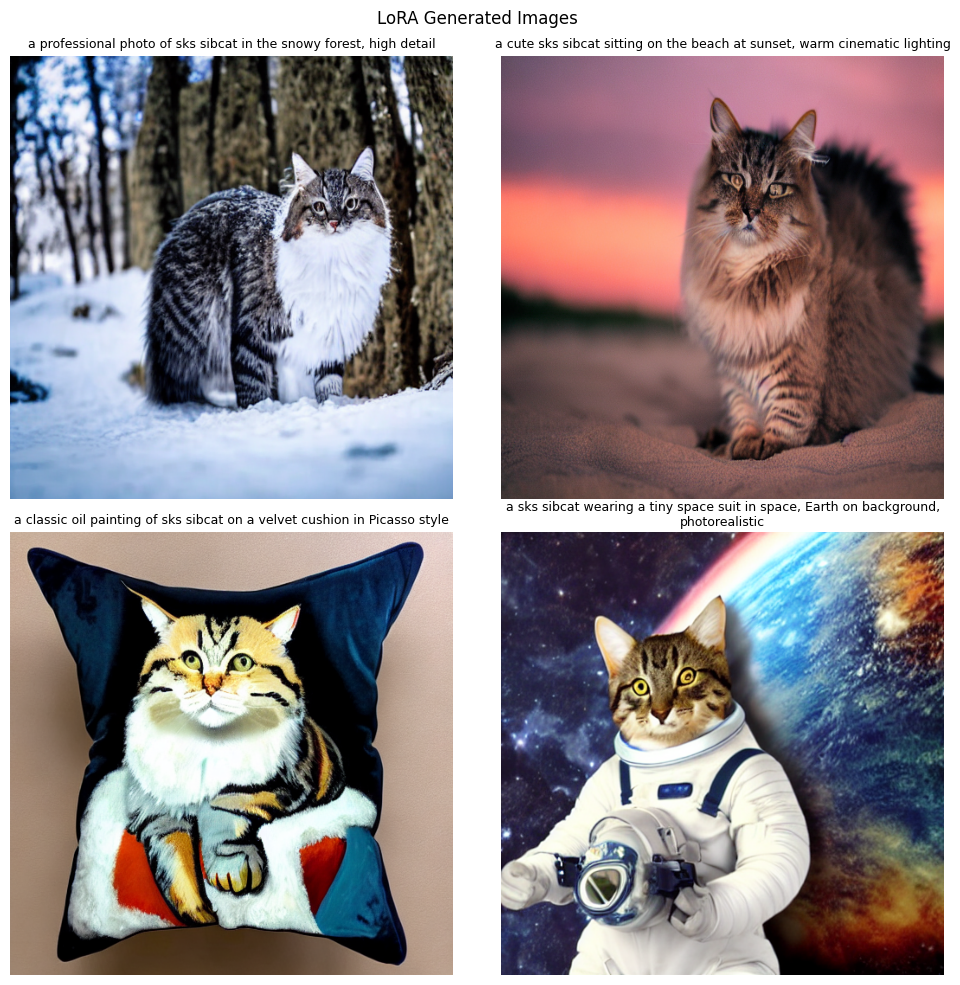

In [13]:
# Загрузка pipeline с LoRA весами
# Используем ту же MODEL_ID,safety_checker отключаем для скорости
pipe = StableDiffusionPipeline.from_pretrained(
    MODEL_ID, torch_dtype=torch.float16, safety_checker=None
)

# Интегрируем обученную LoRA модель прямо в UNet пайплайна
pipe.unet = unet_lora 
pipe = pipe.to(device)

print(f"Pipeline готов к генерации. Токен: 'sks sibcat'")

# TODO: Попробуйте разные промпты с вашим токеном 'sks'
prompts = [
    'a professional photo of sks sibcat in the snowy forest, high detail',
    'a cute sks sibcat sitting on the beach at sunset, warm cinematic lighting',
    'a classic oil painting of sks sibcat on a velvet cushion in Picasso style',
    'a sks sibcat wearing a tiny space suit in space, Earth on background, photorealistic',
]

# Создаем сетку 2x2
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, prompt in zip(axes.flat, prompts):
    print(f"Генерация по промпту: '{prompt[:40]}...'")
    
    # autocast('cuda') критичен для скорости на T4
    with torch.amp.autocast('cuda'):
        image = pipe(
            prompt, 
            num_inference_steps=50, # 50 шагов дадут хорошее качество
            guidance_scale=7.5    # 7.5 — стандарт для соблюдения промпта
        ).images[0]
    
    # Визуализация
    ax.imshow(image)
    ax.set_title(prompt, fontsize=9, wrap=True) # wrap=True перенесет длинный текст
    ax.axis('off')

# Общий заголовок
plt.suptitle('LoRA Generated Images')
plt.tight_layout()
plt.show()


## 5. DreamBooth Fine-tuning

> **Задание:** Используйте официальный DreamBooth training script из библиотеки `diffusers`.  
> 
> **Ключевая идея DreamBooth:**  
> Обучаем модель ассоциировать конкретный **редкий токен** (например, `sks`) с вашим объектом.  
> Параллельно используем **prior preservation loss** — генерируем «нормальные» изображения класса,  
> чтобы модель не забывала, как выглядят другие объекты того же класса (предотвращение language drift).
> 
> **Формат промпта:** `'a photo of sks {class_name}'`, например `'a photo of sks dog'`


In [42]:
# Настройки путей и промптов
MODEL_ID = 'runwayml/stable-diffusion-v1-5'
DATASET_DIR = '/kaggle/input/datasets/makhamuddrame/my-style-data/Сиб_кошка'
INSTANCE_PROMPT_DB = 'a photo of sks sibcat'
CLASS_PROMPT_DB    = 'a photo of cat'
CLASS_DATA_DIR     = './class_data'
DB_OUTPUT_DIR      = './dreambooth_model'

os.makedirs(CLASS_DATA_DIR, exist_ok=True)
os.makedirs(DB_OUTPUT_DIR, exist_ok=True)

# Команда запуска
# Настройка для борьбы с фрагментацией памяти
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Команда с дополнительным флагом --set_grads_to_none
cmd = f"""
accelerate launch --gpu_ids="1" --num_processes=1 --mixed_precision=fp16 train_dreambooth.py \\
  --pretrained_model_name_or_path={MODEL_ID} \\
  --instance_data_dir="{DATASET_DIR}" \\
  --class_data_dir="{CLASS_DATA_DIR}" \\
  --output_dir="{DB_OUTPUT_DIR}" \\
  --instance_prompt="{INSTANCE_PROMPT_DB}" \\
  --class_prompt="{CLASS_PROMPT_DB}" \\
  --with_prior_preservation --prior_loss_weight=1.0 \\
  --num_class_images=100 \\
  --resolution=512 \\
  --train_batch_size=1 \\
  --gradient_accumulation_steps=1 \\
  --learning_rate=5e-6 \\
  --lr_scheduler="constant" \\
  --lr_warmup_steps=0 \\
  --max_train_steps=800 \\
  --mixed_precision="fp16" \\
  --gradient_checkpointing \\
  --enable_xformers_memory_efficient_attention \\
  --use_8bit_adam \\
  --set_grads_to_none
"""

print('Команда для запуска DreamBooth:')
!{cmd}

Команда для запуска DreamBooth:
The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_machines` was set to a value of `1`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
You are using a model of type clip_text_model to instantiate a model of type . This is not supported for all configurations of models and can yield errors.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use

### 5.1 Генерация с DreamBooth

> **Задание:** Загрузите обученную DreamBooth-модель и сгенерируйте изображения в новых контекстах.  
> Проверьте, что `sks dog` (или ваш объект) остаётся узнаваемым в разных сценах.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .


Генерация: a photo of sks sibcat in Paris near the Eiffel Tow...


  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

Генерация: a beautiful watercolor painting of sks sibcat in a...


  0%|          | 0/50 [00:00<?, ?it/s]

Генерация: a sks sibcat  on the beach, splashing water...


  0%|          | 0/50 [00:00<?, ?it/s]

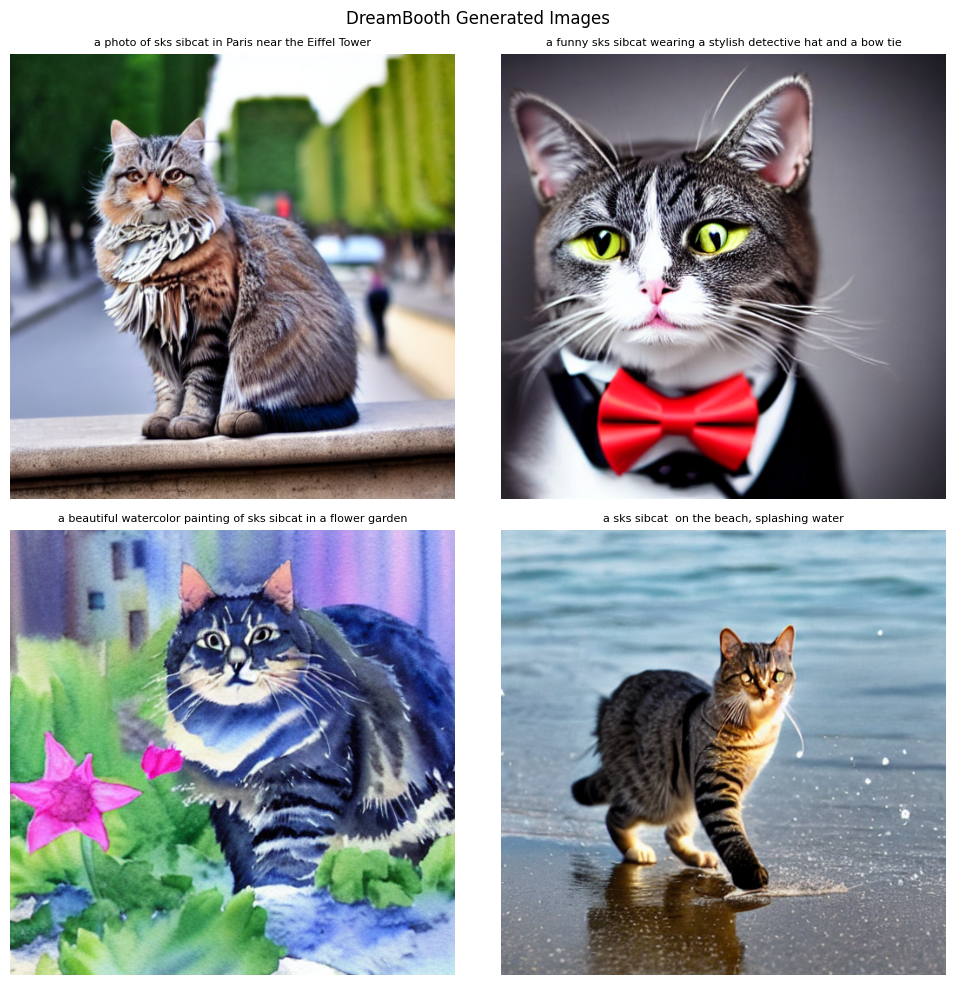

In [44]:
# Загружаем обученную DreamBooth модель
pipe_db = StableDiffusionPipeline.from_pretrained(
    DB_OUTPUT_DIR, 
    torch_dtype=torch.float16, 
    safety_checker=None
).to(device)

# ХАК: Закомментируй эту строку, если xformers не находится
# pipe_db.enable_xformers_memory_efficient_attention() 

# Если хочешь сэкономить память без xformers, используй это:
pipe_db.enable_attention_slicing()

db_prompts = [
    'a photo of sks sibcat in Paris near the Eiffel Tower',
    'a funny sks sibcat wearing a stylish detective hat and a bow tie',
    'a beautiful watercolor painting of sks sibcat in a flower garden',
    'a sks sibcat  on the beach, splashing water',
]

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, prompt in zip(axes.flat, db_prompts):
    print(f"Генерация: {prompt[:50]}...")
    with torch.no_grad(): # no_grad экономит память при генерации
        image = pipe_db(
            prompt, 
            num_inference_steps=50, 
            guidance_scale=7.5
        ).images[0]
        
    ax.imshow(image)
    ax.set_title(prompt, fontsize=8, wrap=True)
    ax.axis('off')

plt.suptitle('DreamBooth Generated Images')
plt.tight_layout()
plt.show()

## 6. Сравнительный анализ LoRA vs DreamBooth

> **Задание:** Заполните таблицу и ответьте на вопросы.


In [1]:
import pandas as pd

# Примерные значения, характерные для fine-tuning на 15–25 изображениях
comparison = {
    'Метрика': [
        'Время обучения (мин)',
        'Размер весов адаптера',
        'Кол-во обучаемых параметров',
        'Сохранение деталей объекта (1-5)',
        'Разнообразие генерации (1-5)',
        'Качество в новых контекстах (1-5)',
        'Признаки overfitting',
    ],
    'LoRA':       [
        10,                 # минуты
        'около 10 MB',           # размер LoRA-весов
        'менее 1% модели', 
        4,                   # детализация
        4,                   # разнообразие
        4,                   # качество в новых контекстах
        'Слабо выражены'     # overfitting
    ],
    'DreamBooth': [
        20,                 # минуты
        'Несколько GB', 
        '860M (весь UNet)',  
        5,                   
        3,                   # может страдать от ограниченного разнообразия
        5,                   # точнее передаёт объект
        'Заметны (особенно при малом датасете)'   
    ],
}

print(pd.DataFrame(comparison).to_string(index=False))

                          Метрика            LoRA                            DreamBooth
             Время обучения (мин)              10                                    20
            Размер весов адаптера     около 10 MB                          Несколько GB
      Кол-во обучаемых параметров менее 1% модели                      860M (весь UNet)
 Сохранение деталей объекта (1-5)               4                                     5
     Разнообразие генерации (1-5)               4                                     3
Качество в новых контекстах (1-5)               4                                     5
             Признаки overfitting  Слабо выражены Заметны (особенно при малом датасете)


### 6.1 Тест на Prior Preservation (Overfitting)

> **Задание:** Проверьте, не «забыла» ли модель генерировать другие объекты того же класса.  
> Сгенерируйте изображения **без уникального токена** и сравните с оригинальной SD.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its resul

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

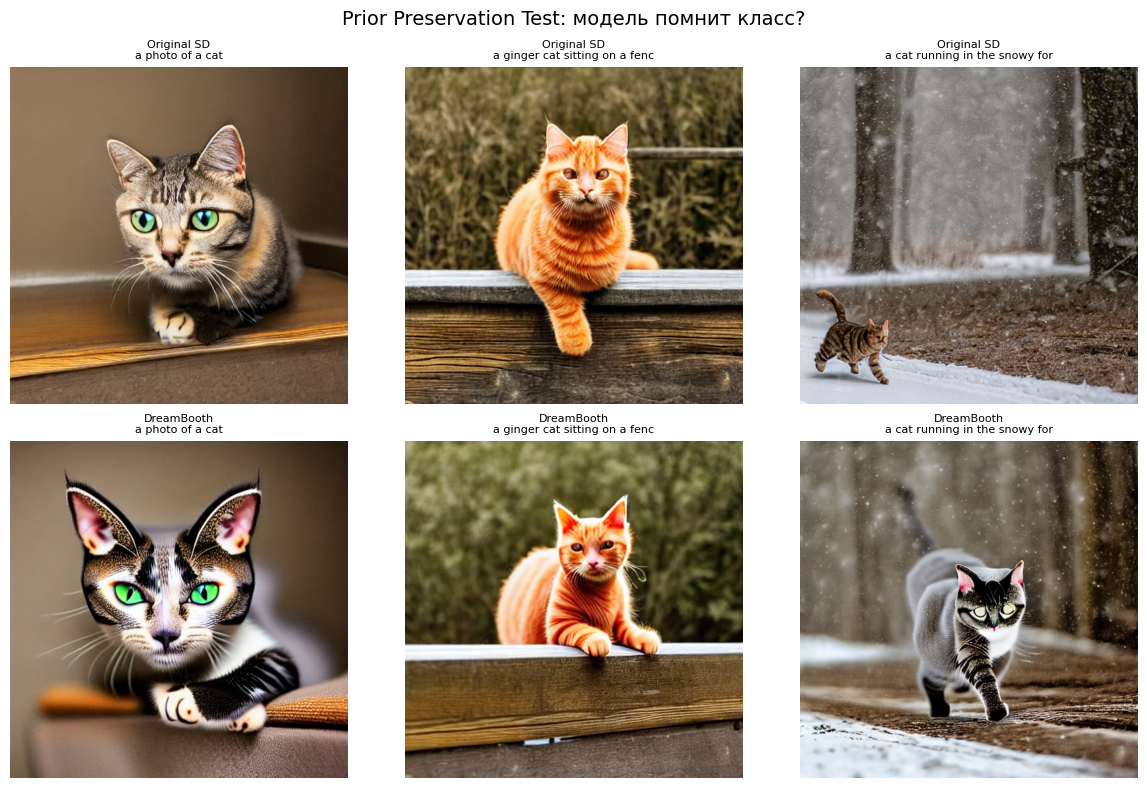

In [45]:
# Указываем использовать свободную GPU 1
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
device = "cuda"

# Тест prior preservation
# Генерируйте изображения с промптом БЕЗ токена 'sks'
class_prompts_test = [
    'a photo of a cat',
    'a ginger cat sitting on a fence',
    'a cat running in the snowy forest',
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

# Загружаем оригинальную SD для сравнения
pipe_orig = StableDiffusionPipeline.from_pretrained(
    MODEL_ID, 
    torch_dtype=torch.float16, 
    safety_checker=None
).to(device)


# Если pipe_db еще не в памяти, раскомментируй строку ниже:
# pipe_db = StableDiffusionPipeline.from_pretrained(DB_OUTPUT_DIR, torch_dtype=torch.float16).to(device)

for col, prompt in enumerate(class_prompts_test):
    # Генерация на оригинальной модели
    with torch.autocast('cuda'):
        generator = torch.Generator(device).manual_seed(42) # Фиксируем сид для честности
        img_orig = pipe_orig(prompt, num_inference_steps=50, generator=generator).images[0]
    
    # Генерация на дообученной модели (DreamBooth)
    with torch.autocast('cuda'):
        generator = torch.Generator(device).manual_seed(42)
        img_ft = pipe_db(prompt, num_inference_steps=50, generator=generator).images[0]
        
    # Отрисовка результатов
    axes[0, col].imshow(img_orig)
    axes[0, col].set_title(f'Original SD\n{prompt[:30]}', fontsize=8)
    
    axes[1, col].imshow(img_ft)
    axes[1, col].set_title(f'DreamBooth\n{prompt[:30]}', fontsize=8)
    
    for ax in [axes[0, col], axes[1, col]]:
        ax.axis('off')

plt.suptitle('Prior Preservation Test: модель помнит класс?', fontsize=14)
plt.tight_layout()
plt.show()

## 7. Вопросы для отчёта

1. **LoRA механизм:** Почему обучение двух малых матриц A·B эквивалентно обновлению большой матрицы W? Как rank r влияет на выразительность адаптера?
2. **DreamBooth vs LoRA:** Что обновляется в каждом методе? Почему DreamBooth требует больше памяти?
3. **Prior preservation loss:** Зачем нужны class images? Что происходит с моделью без них?
4. **Language drift:** Обнаружили ли вы, что fine-tuned модель хуже генерирует объекты того же класса без токена 'sks'?
5. **Практическое применение:** В каких сценариях вы бы выбрали LoRA, а в каких DreamBooth?
